In [ ]:
!pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 56.0 MB/s eta 0:00:00


In [ ]:
!unzip data.zip

Archive:  data.zip
  inflating: UCI HAR Dataset/README.txt  
  inflating: UCI HAR Dataset/features_info.txt  
  inflating: UCI HAR Dataset/features.txt  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: UCI HAR Dataset/train/subject_train.txt  
  inflating: UCI HAR Dataset/train/y_train.txt  
  inflating: UCI HAR Dataset/test/subject_test.txt  
  inflating: UCI HAR Dataset/test/y_test.txt  
  inflating: UCI HAR Dataset/train/Inertial Signals/total_acc_y_train.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/total_acc_z_test.txt  
  inflating: UCI HAR Dataset/train/Inertial Signals/body_gyro_z_train.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/total_acc_y_test.txt  
  inflating: UCI HAR Dataset/train/Inertial Signals/total_acc_x_train.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_gyro_y_test.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/total_acc_x_test.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_gyro_z_test

In [ ]:
import numpy as np
import os

DATA_DIR = "/content/UCI HAR Dataset/"

def load_signal(file):
    return np.loadtxt(file)

def load_group(files):
    data = [load_signal(os.path.join(DATA_DIR, f)) for f in files]
    return np.stack(data, axis=1)

train_files = [
    "train/Inertial Signals/body_acc_x_train.txt",
    "train/Inertial Signals/body_acc_y_train.txt",
    "train/Inertial Signals/body_acc_z_train.txt",
    "train/Inertial Signals/body_gyro_x_train.txt",
    "train/Inertial Signals/body_gyro_y_train.txt",
    "train/Inertial Signals/body_gyro_z_train.txt",
]

test_files = [
    "test/Inertial Signals/body_acc_x_test.txt",
    "test/Inertial Signals/body_acc_y_test.txt",
    "test/Inertial Signals/body_acc_z_test.txt",
    "test/Inertial Signals/body_gyro_x_test.txt",
    "test/Inertial Signals/body_gyro_y_test.txt",
    "test/Inertial Signals/body_gyro_z_test.txt",
]

X_train_raw = load_group(train_files)
X_test_raw  = load_group(test_files)

print("Raw shapes:", X_train_raw.shape, X_test_raw.shape)

Raw shapes: (7352, 6, 128) (2947, 6, 128)


In [ ]:
import numpy as np

def gasf_transform(signal):
    x = (signal - signal.min()) / (signal.max() - signal.min() + 1e-8)
    x = 2*x - 1
    phi = np.arccos(x)
    gasf = np.cos(phi[:,None] + phi[None,:])
    return gasf.astype(np.float32)

In [ ]:
import torch
from torch.utils.data import Dataset

class HAR_GASF_Dataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        sample = self.X[i]
        chans = []

        for axis in sample:
            gasf = gasf_transform(axis)
            chans.append(gasf)

        x = np.stack(chans, axis=0)
        x = torch.from_numpy(x).float()
        y = torch.tensor(self.y[i]).long()
        return x, y

In [ ]:
import os
import numpy as np

y_train_path = os.path.join(DATA_DIR, "train/y_train.txt")
y_test_path  = os.path.join(DATA_DIR, "test/y_test.txt")

y_train = np.loadtxt(y_train_path).astype(np.int32) - 1
y_test  = np.loadtxt(y_test_path).astype(np.int32) - 1

print(y_train.shape, y_test.shape)

(7352,) (2947,)


In [ ]:
from torch.utils.data import DataLoader

train_dl = DataLoader(
    HAR_GASF_Dataset(X_train_raw, y_train),
    batch_size=32, shuffle=True, num_workers=0, pin_memory=True
)

test_dl = DataLoader(
    HAR_GASF_Dataset(X_test_raw, y_test),
    batch_size=32, shuffle=False, num_workers=0, pin_memory=True
)

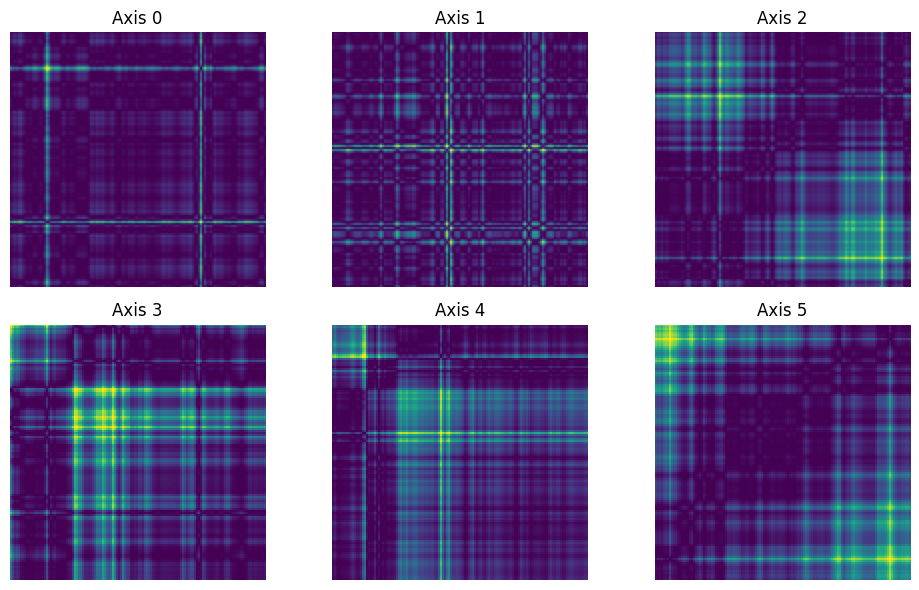

In [58]:
import matplotlib.pyplot as plt

def show_axes_wise_gasf(x, y, sample_idx=0):
    sample = x[sample_idx]
    label = y[sample_idx].item()

    fig, axs = plt.subplots(2, 3, figsize=(10, 6))
    axs = axs.flatten()

    for i in range(6):
        axs[i].imshow(sample[i], cmap="viridis")
        axs[i].set_title(f"Axis {i}")
        axs[i].axis("off")

    plt.tight_layout()
    plt.show()


x, y = next(iter(train_dl))
show_axes_wise_gasf(x, y, sample_idx=0)

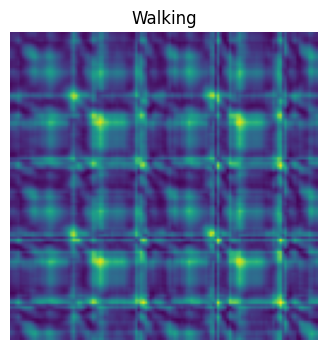

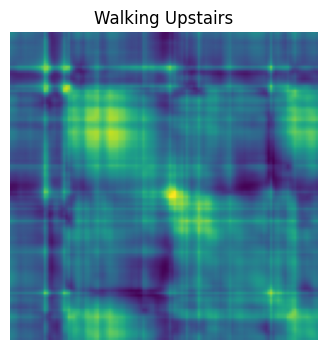

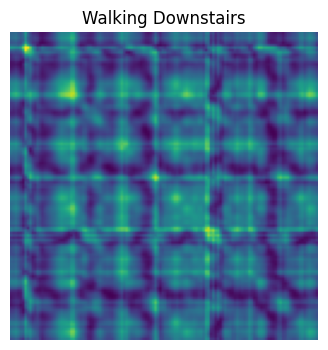

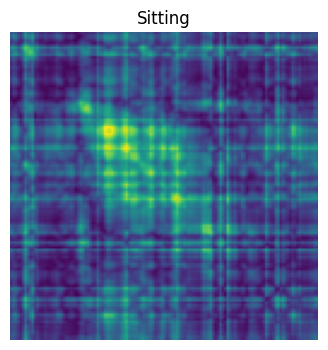

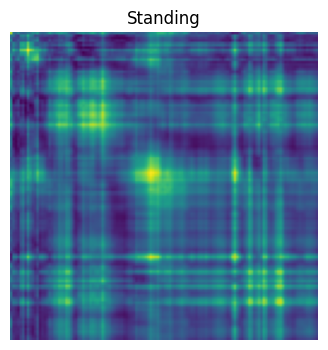

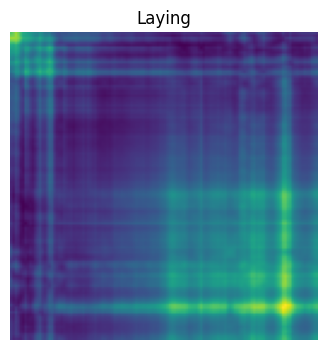

In [59]:
import torch
import matplotlib.pyplot as plt

activity_names = {
    0: "Walking",
    1: "Walking Upstairs",
    2: "Walking Downstairs",
    3: "Sitting",
    4: "Standing",
    5: "Laying"
}

def show_activity_merged_gasf(dataloader, activity_id):
    for x, y in dataloader:
        idxs = (y == activity_id).nonzero(as_tuple=True)[0]
        if len(idxs) > 0:
            sample = x[idxs[0]]
            break

    merged = sample.mean(dim=0)

    plt.figure(figsize=(4, 4))
    plt.imshow(merged, cmap="viridis")
    plt.title(activity_names.get(activity_id, f"Activity {activity_id}"))
    plt.axis("off")
    plt.show()


for act in activity_names:
    show_activity_merged_gasf(train_dl, act)

In [ ]:
x, y = next(iter(train_dl))
print(x.shape, y.shape)

torch.Size([32, 6, 128, 128]) torch.Size([32])


In [ ]:
y_train = np.loadtxt(DATA_DIR+"train/y_train.txt").astype(int) - 1
y_test  = np.loadtxt(DATA_DIR+"test/y_test.txt").astype(int) - 1

In [ ]:
x, y = next(iter(train_dl))
print("Batch X:", x.shape)
print("Batch Y:", y.shape)

Batch X: torch.Size([32, 6, 128, 128])
Batch Y: torch.Size([32])


In [ ]:
import torch
import torch.nn as nn
import timm
import math


class ViT6Pretrained(nn.Module):
    def __init__(self, num_classes, image_size=128, patch_size=16):
        super().__init__()

        self.vit = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=num_classes
        )

        old = self.vit.patch_embed.proj
        self.vit.patch_embed.proj = nn.Conv2d(
            in_channels=6,
            out_channels=old.out_channels,
            kernel_size=old.kernel_size,
            stride=old.stride,
            padding=old.padding,
            bias=old.bias is not None
        )

        with torch.no_grad():
            self.vit.patch_embed.proj.weight[:, :3] = old.weight
            self.vit.patch_embed.proj.weight[:, 3:] = 0.0

        pos = self.vit.pos_embed[:, 1:, :]
        num_patches = (image_size // patch_size) ** 2
        pos = pos.reshape(1, int(math.sqrt(pos.shape[1])), int(math.sqrt(pos.shape[1])), -1)
        pos = torch.nn.functional.interpolate(
            pos.permute(0, 3, 1, 2),
            size=(image_size // patch_size, image_size // patch_size),
            mode="bicubic",
            align_corners=False
        ).permute(0, 2, 3, 1).reshape(1, num_patches, -1)

        cls_tok = self.vit.pos_embed[:, :1, :]
        self.vit.pos_embed = nn.Parameter(torch.cat([cls_tok, pos], dim=1))

        self.vit.patch_embed.img_size = (image_size, image_size)
        self.vit.patch_embed.strict_img_size = False
        self.vit.img_size = image_size


    def forward(self, x):
        return self.vit(x)

In [ ]:
device = "cuda"
num_classes = len(set(y_train))

model = ViT6Pretrained(num_classes).to(device)
print("Model ready ✔")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model ready ✔


In [ ]:
for name, module in model.named_children():
    print(name, " -> ", type(module))

vit  ->  <class 'timm.models.vision_transformer.VisionTransformer'>


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

device = "cuda" if torch.cuda.is_available() else "cpu"

train_dl = DataLoader(HAR_GASF_Dataset(X_train_raw, y_train),
                      batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
test_dl = DataLoader(HAR_GASF_Dataset(X_test_raw, y_test),
                     batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

model.to(device)
for p in model.parameters():
    p.requires_grad = True

optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=16)

criterion = nn.CrossEntropyLoss()


print("GASF Fine-tuning setup")


GASF Fine-tuning setup


In [ ]:
from tqdm.auto import tqdm
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler()

EPOCHS = 18

for epoch in range(EPOCHS):
    model.train()
    loop = tqdm(train_dl, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for x, y in loop:
        x = x.to(device, non_blocking=True)
        y = y.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type = "cuda"):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loop.set_postfix(loss=float(loss))

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_dl:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    print("Val Acc:", correct / total)

/tmp/ipython-input-1578040635.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/18:   0%|          | 0/230 [00:00<?, ?it/s]

Val Acc: 0.7288768238887003


Epoch 2/18:   0%|          | 0/230 [00:00<?, ?it/s]

Val Acc: 0.7292161520190024


...

Val Acc: 0.7665422463522226


Epoch 17/18:   0%|          | 0/230 [00:00<?, ?it/s]

Val Acc: 0.7034272141160502


Epoch 18/18:   0%|          | 0/230 [00:00<?, ?it/s]

Val Acc: 0.7784187309127927


In [ ]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(1)

        test_correct += (preds == y).sum().item()
        test_total   += y.size(0)

test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.7784


In [ ]:
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)

        probs = torch.softmax(logits, dim=1)

        preds = probs.argmax(1)

        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y.cpu().numpy())

all_preds  = np.concatenate(all_preds)
all_probs  = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
acc = accuracy_score(all_labels, all_preds)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0
)

prec_weight, rec_weight, f1_weight, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

try:
    auroc_macro = roc_auc_score(
        all_labels, all_probs,
        multi_class="ovr",
        average="macro"
    )
except Exception:
    auroc_macro = None

print("GASF+FINE_TUNING")

print("\n===== TEST METRICS =====")
print(f"Accuracy        : {acc:.4f}")
print(f"Precision (macro): {prec_macro:.4f}")
print(f"Recall (macro)   : {rec_macro:.4f}")
print(f"F1-Score (macro) : {f1_macro:.4f}")
print(f"Precision (weighted): {prec_weight:.4f}")
print(f"Recall (weighted)   : {rec_weight:.4f}")
print(f"F1-Score (weighted) : {f1_weight:.4f}")

if auroc_macro is not None:
    print(f"AUROC (macro-OvR): {auroc_macro:.4f}")
else:
    print("AUROC: not defined (check class probabilities)")

GASF+FINE_TUNING

===== TEST METRICS =====
Accuracy        : 0.7784
Precision (macro): 0.7918
Recall (macro)   : 0.7854
F1-Score (macro) : 0.7864
Precision (weighted): 0.7847
Recall (weighted)   : 0.7784
F1-Score (weighted) : 0.7793
AUROC (macro-OvR): 0.9588


In [ ]:
pip install numpy matplotlib seaborn scikit-learn pyts torch torchvision

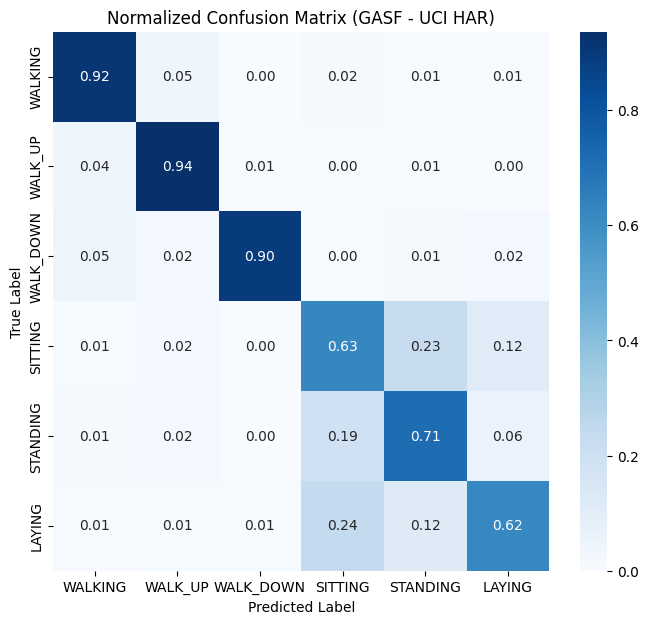

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, test_loader, class_names):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_true.extend(y.numpy())
            y_pred.extend(preds)

    cm = confusion_matrix(y_true, y_pred, normalize="true")

    plt.figure(figsize=(8, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Normalized Confusion Matrix (GASF - UCI HAR)")
    plt.show()

class_names = [
    "WALKING",
    "WALK_UP",
    "WALK_DOWN",
    "SITTING",
    "STANDING",
    "LAYING"
]

plot_confusion_matrix(model, test_dl, class_names)


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

activities = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Lying"
]

report = classification_report(all_labels, all_preds, output_dict=True)
acc = accuracy_score(all_labels, all_preds) * 100
rows = []

for i, act in enumerate(activities):
    rows.append([
        act,
        round(report[str(i)]['precision'] * 100, 2),
        round(report[str(i)]['recall'] * 100, 2),
        round(report[str(i)]['f1-score'] * 100, 2),
        round(acc, 2)
    ])

df_ieee = pd.DataFrame(rows, columns=[
    "Activity", "Precision (%)", "Recall (%)", "F1-score (%)", "Accuracy (%)"
])

df_ieee

,Activity,Precision (%),Recall (%),F1-score (%),Accuracy (%)
0,Walking,89.39,91.73,90.55,77.84
1,Walking Upstairs,88.55,93.63,91.02,77.84
2,Walking Downstairs,97.66,89.52,93.42,77.84
3,Sitting,56.00,62.73,59.17,77.84
4,Standing,66.67,71.43,68.97,77.84
5,Lying,76.78,62.20,68.72,77.84
